# Lee-norm CRT Reconstruction (Shparlinski--Steinfeld 2004)

Monte Carlo simulation of the lattice-based Lee-norm decoder from
*I.E. Shparlinski, R. Steinfeld, "Noisy Chinese remaindering in the Lee norm",*
*Journal of Complexity 20 (2004) 423--437.*

**Setup matches the naive-CRT script:** same prime sets, same POPT noise model on the remainders, same true value $\mathfrak{T}=47536.8$, same plotting style.

**Algorithm in one paragraph.** Given noisy residues $y_i \approx a \bmod p_i$ with Lee-norm error bound $\|e\|_{L,\mathbf{p}} < h$, build the $(n+1)$-dimensional Shparlinski--Steinfeld lattice (Eq. 3 of the paper) so that every integer $c$ corresponds to a lattice vector $(\langle c\rangle_{p_1},\ldots,\langle c\rangle_{p_n}, ch/K)$. Solve the closest-vector problem (CVP) with target $\bar y = (y_1,\ldots,y_n, 0)$ to recover an integer $c$ near the true $a$. Then a short post-processing loop (Steps 4--6 of `LeeDecode`) cleans up the CVP approximation and returns the interval $[a^*, b^*]$ of *all* integers in $[0,K)$ whose residue vector is within Lee distance $h$ of $y$.

**Requires:** `fpylll` (which needs `cysignals`). Install with
```bash
pip install cysignals fpylll
```

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from math import gcd, prod, lcm, ceil, floor
from functools import reduce
import matplotlib as mpl

from fpylll import IntegerMatrix, LLL, CVP

mpl.rcParams.update({
    'text.usetex'         : True,
    'text.latex.preamble' : r'\usepackage{mathptmx} \usepackage{amssymb}',
    'font.family'         : 'serif',
    'font.size'           : 28,
    'axes.titlesize'      : 24,
    'axes.labelsize'      : 24,
    'xtick.labelsize'     : 30,
    'ytick.labelsize'     : 30,
    'legend.fontsize'     : 24,
    'axes.linewidth'      : 1.8,
    'figure.dpi'          : 150,
})

## POPT noise model (identical to the naive-CRT script)

In [6]:
def popt_pdf(phi, N):
    phi   = np.asarray(phi, dtype=float)
    alpha = np.pi / N
    num   = (1.0 + np.cos(N * phi)) * (1.0 + np.cos(phi))
    den   = (1.0 - np.cos(phi + alpha)) * (1.0 - np.cos(phi - alpha))
    lim   = N**2 * (1.0 + np.cos(phi)) / (2.0 * np.sin(alpha)**2)
    near  = np.abs(den) < 1e-12
    return np.where(near, lim, np.maximum(num / np.where(near, 1.0, den), 0.0))

_popt_cache_naive = {}

def sample_popt_naive(N, size, rng, n_grid=400_000):
    if N not in _popt_cache_naive:
        phi_grid = np.linspace(-np.pi + 1e-8, np.pi - 1e-8, n_grid)
        pdf      = popt_pdf(phi_grid, N)
        cdf      = np.cumsum(pdf) * (phi_grid[1] - phi_grid[0])
        cdf     /= cdf[-1]
        _popt_cache_naive[N] = (phi_grid, cdf)
    phi_grid, cdf = _popt_cache_naive[N]
    return np.interp(rng.uniform(size=size), cdf, phi_grid)

## Lee-norm helpers

Following the paper's Section 2: for a prime $p$ and integer $z$, the Lee norm modulo $p$ is
$$
\|z\|_{L,p} = |\langle z\rangle_p|
$$
where $\langle z\rangle_p$ is the smallest-absolute-value representative in $(-p/2, p/2]$.

In [7]:
def lee_residue(z, p):
    """Smallest-absolute-value representative <z>_p in (-p/2, p/2]."""
    r = z % p
    if r > p // 2:
        r -= p
    return r

def lee_dist(a, y, moduli):
    """max_i ||a - y_i||_{L,p_i} over the prime base."""
    return max(abs(lee_residue(a - yi, p)) for yi, p in zip(y, moduli))

## CVP on the Shparlinski--Steinfeld lattice

Eq. (3) of the paper defines the lattice basis (rows)
$$
B = \begin{pmatrix}
p_1 & 0 & \cdots & 0 & 0 \\
0 & p_2 & \cdots & 0 & 0 \\
\vdots & & \ddots & & \vdots \\
0 & 0 & \cdots & p_n & 0 \\
1 & 1 & \cdots & 1 & h/K
\end{pmatrix}.
$$
Every integer $c$ corresponds to the lattice vector $(\langle c\rangle_{p_1},\ldots,\langle c\rangle_{p_n}, ch/K)$. To use integer LLL we multiply the entire basis and target by $K$, preserving Euclidean geometry. The last column then carries integer $h$ instead of $h/K$, and we recover $c$ from the closest-vector output by dividing the last coordinate by $h$.

In [8]:
def cvp_ss_lattice(y, moduli, h, K):
    """Exact CVP on the SS lattice; returns the integer c whose lattice
    vector is closest to the target (y_1, ..., y_n, 0)."""
    n     = len(moduli)
    K_int = int(K)
    h_int = int(h)

    rows = []
    for i in range(n):
        row = [0] * (n + 1)
        row[i] = K_int * int(moduli[i])
        rows.append(row)
    rows.append([K_int] * n + [h_int])

    B = IntegerMatrix.from_matrix(rows)
    LLL.reduction(B)

    target = tuple(int(round(K_int * yi)) for yi in y) + (0,)
    v      = list(CVP.closest_vector(B, target))

    c = v[-1] // h_int if v[-1] % h_int == 0 else int(round(v[-1] / h_int))
    return c

## `LeeDecode` (Algorithm of Section 5)

1. **Step 3**: solve CVP, get integer $c$.
2. **Step 4**: $a \leftarrow \max(0, \lceil c - (\gamma+1)h\rceil)$ (with $\gamma = 1$ since we use exact CVP).
3. **Step 5**: while $d_{L,\mathbf{p}}(a_\mathbf{p}, y) \geq h$, advance $a$ using the residue-jump rule (5a/5b).
4. **Step 6**: compute upper endpoint $b^*$.

*Practical patch*: if the CVP output lies outside $[0, K)$ (which can happen for "bad" prime bases in the SS sense), we wrap $c$ mod $K$ before Step 4 since the residue vector is invariant.

In [9]:
def lee_decode(y, moduli, K, h, gamma=1.0):
    """Returns (a_star, b_star) -- interval of all b in [0,K) with
    Lee distance d_L(b_p, y) < h."""
    # Step 3: CVP
    c = cvp_ss_lattice(y, moduli, h, K) % K

    # Step 4
    a = max(0, int(ceil(c - (gamma + 1) * h)))

    # Step 5: residue-jump loop
    max_iters = max(4 * len(moduli), 50)
    for _ in range(max_iters):
        residues = [lee_residue(a - y[i], p) for i, p in enumerate(moduli)]
        if max(abs(r) for r in residues) < h:
            break
        advanced = False
        for i, (r, p) in enumerate(zip(residues, moduli)):
            if r >= h:
                a = a + p - (h - 1) - r       # Step 5a
                advanced = True
                break
        if advanced:
            continue
        for i, (r, p) in enumerate(zip(residues, moduli)):
            if r <= -h:
                a = a - (h - 1) - r           # Step 5b
                advanced = True
                break
        if not advanced:
            break

    a_star = a
    residues = [lee_residue(a_star - y[i], p) for i, p in enumerate(moduli)]
    b_star   = min(K - 1, a_star + (h - 1) - max(residues))
    return a_star, b_star

## Simulation parameters

Same prime sets, true value, and trial count as the naive-CRT script. The Lee bound $h$ must exceed the worst-case noise magnitude: noise on residue $i$ is $\phi_i\cdot p_i^{\mathrm{base}}/(2\pi)$ with $\phi_i\in(-\pi,\pi)$, so $|e_i| < p_i^{\mathrm{base}}/2 \leq 11/2$. We pick $h = 7$.

In [10]:
base_primes  = np.array([2, 3, 5, 7, 11])
prime_sets_r = [
    np.array([2,  3, 5, 7, 11]),
    np.array([3,  5, 11, 13, 19]),
    np.array([5, 11, 13, 19, 31]),
    np.array([7, 11, 19, 29, 43]),
]

N_true   = 47536.8
N_trials = 1000
rng      = np.random.default_rng(42)

H_LEE = int(ceil(max(base_primes) / 2)) + 1
print(f'Lee bound h = {H_LEE}')
print(f'Theorem 3 requires p_i >= 2(gamma+1)h = {4*H_LEE} for guarantees.')

Lee bound h = 7
Theorem 3 requires p_i >= 2(gamma+1)h = 28 for guarantees.


## Run Monte Carlo and plot

Set 1: moduli=[2, 3, 5, 7, 11], M=2310, P_success=0.000, mean width=4.76, median |err|=923.200
Set 2: moduli=[3, 5, 11, 13, 19], M=40755, P_success=0.000, mean width=1.01, median |err|=8164.300
Set 3: moduli=[5, 11, 13, 19, 31], M=421135, P_success=0.000, mean width=1.26, median |err|=5.300
Set 4: moduli=[7, 11, 19, 29, 43], M=1824361, P_success=0.000, mean width=1.04, median |err|=5.300


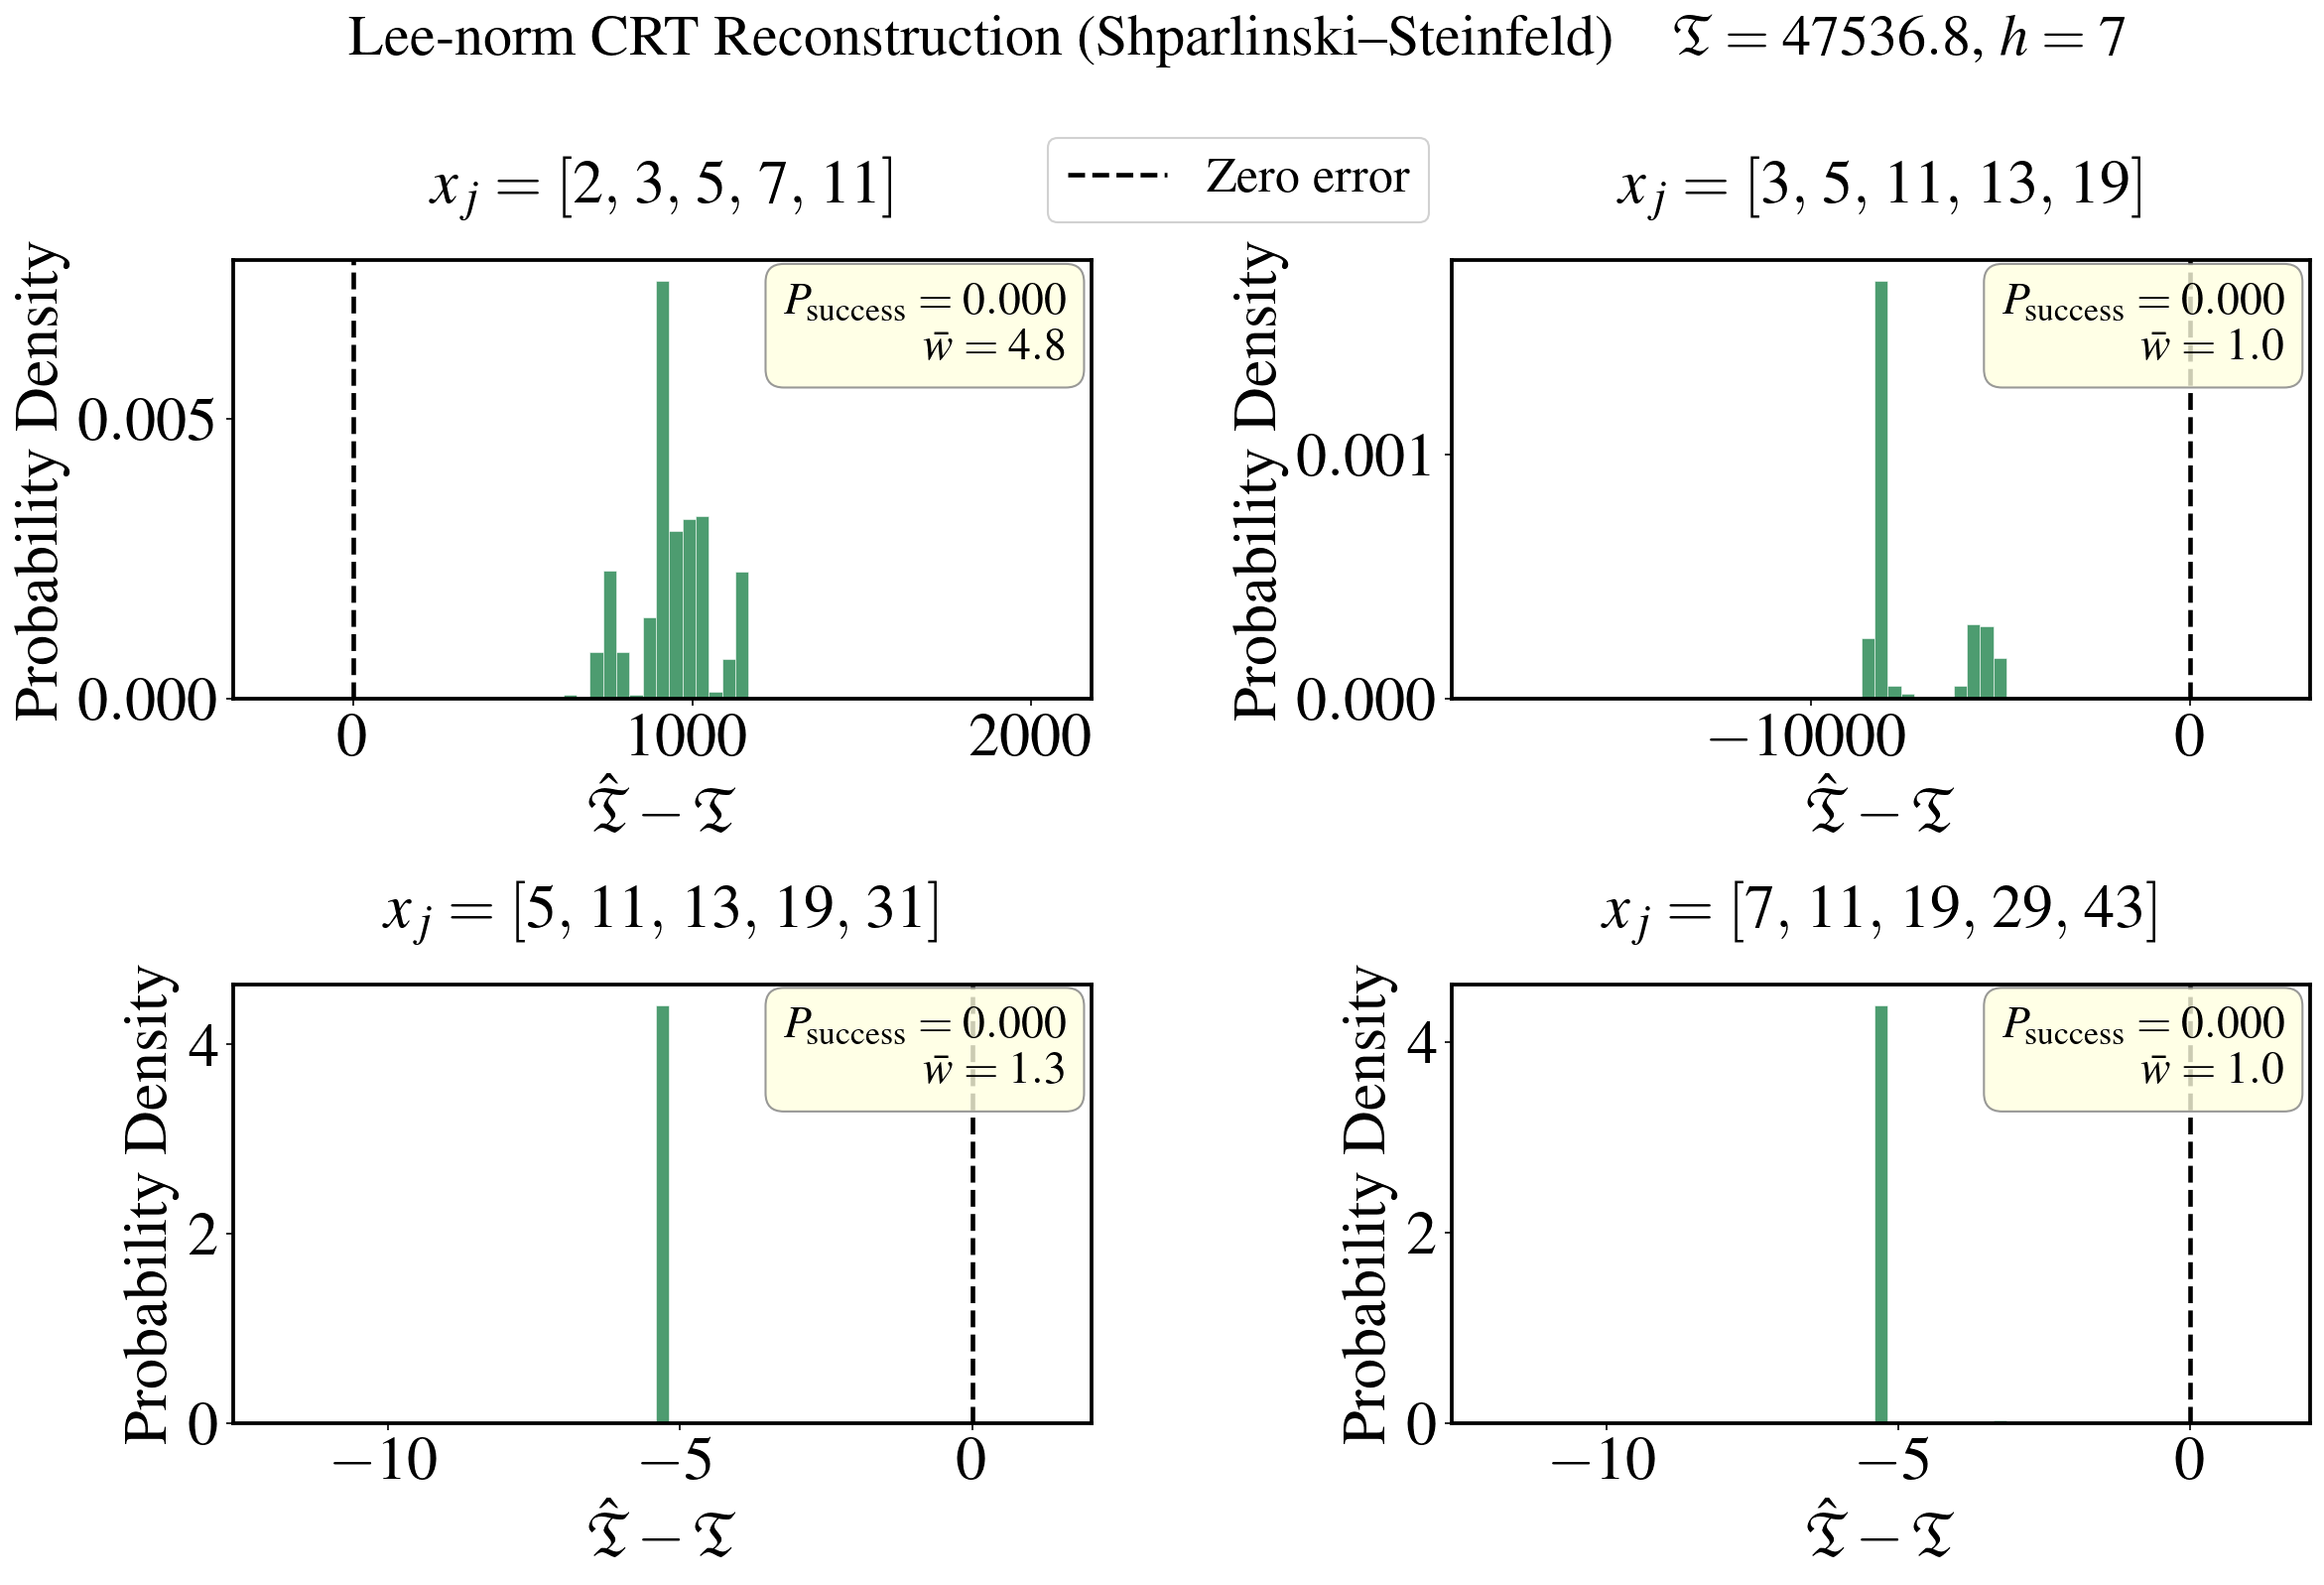

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
plt.subplots_adjust(hspace=0.65, wspace=0.42, top=0.82)

legend_handle = None

for idx, moduli in enumerate(prime_sets_r):
    moduli_list = [int(m) for m in moduli]
    M_lcm       = reduce(lcm, moduli_list)
    K           = M_lcm

    noise_samples = {m: sample_popt_naive(int(m), N_trials, rng) for m in moduli}

    errors = []
    widths = []
    for trial in range(N_trials):
        rems    = [N_true % m for m in moduli_list]
        noise   = [float(noise_samples[int(m)][trial]) * bp / (2 * np.pi)
                   for m, bp in zip(moduli_list, base_primes)]
        noisy_r = [r + n for r, n in zip(rems, noise)]

        # Lee decoder expects integer residues in Z_{p_i}
        y = [int(round(nr)) % p for nr, p in zip(noisy_r, moduli_list)]

        try:
            a_star, b_star = lee_decode(y, moduli_list, K, H_LEE, gamma=1.0)
            est   = 0.5 * (a_star + b_star)
            width = b_star - a_star
        except Exception:
            est, width = M_lcm / 2, K

        err = (est - N_true + M_lcm / 2) % M_lcm - M_lcm / 2
        errors.append(err)
        widths.append(width)

    ax         = axes.flatten()[idx]
    errors_arr = np.array(errors, dtype=float)
    widths_arr = np.array(widths, dtype=float)
    n_within   = int(np.sum(np.abs(errors_arr) < 0.5))
    p_success  = n_within / N_trials

    # Same MAD-based binning as the naive-CRT script
    med   = np.median(errors_arr)
    mad   = max(np.median(np.abs(errors_arr - med)) * 1.4826, 1e-9)
    max_e = max(5 * mad, abs(med) * 1.2, 0.5)
    bins  = np.linspace(med - max_e * 1.05, med + max_e * 1.05, 60)
    ax.hist(errors_arr, bins=bins,
            color='seagreen', edgecolor='white', linewidth=0.3,
            alpha=0.85, density=True)

    line = ax.axvline(0, color='black', linestyle='--', linewidth=2.2,
                      label='Zero error')
    if legend_handle is None:
        legend_handle = line

    moduli_str = r'[' + r',\,'.join(str(m) for m in moduli_list) + r']'
    stats_text = (rf'$P_{{\mathrm{{success}}}} = {p_success:.3f}$' + '\n' +
                  rf'$\bar{{w}} = {np.mean(widths_arr):.1f}$')
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=22,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

    ax.set_title(rf'$x_{{j}} = {moduli_str}$', pad=28, fontsize=30)
    ax.set_xlabel(r'$\hat{\mathfrak{T}} - \mathfrak{T}$', labelpad=10, fontsize=30)
    ax.set_ylabel('Probability Density', fontsize=30)

    print(f'Set {idx+1}: moduli={moduli_list}, M={M_lcm}, '
          f'P_success={p_success:.3f}, mean width={np.mean(widths_arr):.2f}, '
          f'median |err|={np.median(np.abs(errors_arr)):.3f}')

fig.suptitle(
    r'Lee-norm CRT Reconstruction (Shparlinski--Steinfeld)'
    + rf'\quad $\mathfrak{{T}} = {N_true}$, $h = {H_LEE}$',
    fontsize=28, fontweight='bold', y=0.97
)
fig.legend(handles=[legend_handle], loc='upper center',
           bbox_to_anchor=(0.5, 0.91), ncol=1, framealpha=0.9, fontsize=24)

fig.savefig('CRT_lee_norm_popt_simulation.svg', bbox_inches='tight')
fig.savefig('CRT_lee_norm_popt_simulation.pdf', bbox_inches='tight')
plt.show()

## Notes on the result

Three things to keep in mind when reading the histograms:

1. **Operating regime.** Theorem 3 of Shparlinski--Steinfeld requires $p_i \geq 2(\gamma+1)h$ for theoretical guarantees. With $h=7$ that demands every prime to exceed about 28. For the first three prime sets this is violated, so the algorithm operates outside its proven regime and can land on a "bad prime base" (Section 4 of the paper) where the set of valid solutions is not a single contiguous interval.

2. **What success means here.** $P_{\mathrm{success}}$ counts trials where the interval midpoint falls within 0.5 of $\mathfrak{T}$. The interval width $\bar w = (b^* - a^*)$ tells you how confident the decoder thinks it is. A small $\bar w$ with low success rate means the decoder is *confidently wrong*.

3. **The integer assumption.** SS assumes $a \in \mathbb{Z}[K]$. Your $\mathfrak{T} = 47536.8$ is non-integer, so there is an unavoidable $\pm 0.5$ rounding floor on the error even when everything else goes right.